In [15]:
from spd.models.component_utils import (
    # calc_component_acts,
    calc_causal_importances,
    calc_stochastic_masks,
    calc_ci_l_zero,
    component_activation_statistics,
)

from spd.utils import calc_kl_divergence_lm
from spd.models.components import EmbeddingComponent, Gate, GateMLP, LinearComponent
from transformers import AutoTokenizer
import torch
from spd.models.component_model import ComponentModel
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
# model_path = "out/last_mlp/model_50000.pth"
# model_path = "out/decent_run/model_50000.pth"
# model_path = "out/decent_run_100k/model_100000.pth"
# model_path = "out/nmasks1_stochrecon3.00e-01_p2.00e+00_impmin1.00e+00_C300_sd0_lr1.00e-04_bs2_rmsimportance_mlp__pretrainedroneneldan/TinyStories-1M_seq64_20250707_193819_485/model_50000.pth"
model_path = "out/pnorm_0_5/model_50000.pth"
model, config, out_dir = ComponentModel.from_pretrained(model_path)
model.to(device)
model.requires_grad_(False)
model_name = "roneneldan/TinyStories-1M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Create dataloader
dataset = load_dataset("roneneldan/TinyStories", split="train[:10_000]")


# Track specific components
target_modules = {
    "transformer.h.2.mlp.c_fc": [i for i in range(100)],  # module: component_idx
}

module_comp = [key.replace('-', '.') for key in model.components.keys()]


# text = " Once upon a time, a boy named"
text = "One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt."
tokens = torch.tensor([tokenizer.encode(text)])

gates: dict[str, Gate | GateMLP] = {
    k.removeprefix("gates.").replace("-", "."): v for k, v in model.gates.items()
}  # type: ignore
components: dict[str, LinearComponent | EmbeddingComponent] = {
    k.removeprefix("components.").replace("-", "."): v for k, v in model.components.items()
}  
As = {module_name: components[module_name].A for module_name in components}
with torch.no_grad():
    orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
        tokens.to(device),
        module_names = module_comp
    )
    # target_component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)  # type: ignore
    causal_importances, causal_importances_upper_leaky = calc_causal_importances(
        pre_weight_acts=pre_weight_acts, As=As, gates=gates, detach_inputs=False
    )

    # new_mask = masks.copy()
    # new_mask['transformer.h.7.mlp.c_fc'][0, 6, 1534]  = 0.0
    masked_logits = model.forward_with_components(
        tokens.to(device),
        # components=model.components,
        components=components,
        masks=causal_importances
        # masks=new_mask,
    )
    stochastic_masks = calc_stochastic_masks(causal_importances, n_mask_samples=1)[0]
    logits_stochastic = model.forward_with_components(
        tokens.to(device),
        components=components,
        masks=stochastic_masks
    )
    
seq_pos = -2
val, idx = logits_masked_softmax[:, seq_pos].topk(10)
val_o, idx_o = orig_logits[:, seq_pos].topk(10)
print(f"Original: {tokenizer.batch_decode(idx)}, {tokenizer.batch_decode(idx_o)}")

val_s, idx_s = logits_stochastic[:, seq_pos].topk(10)
print(f"Stochastic: {tokenizer.batch_decode(idx_s)}")

from torch.nn import functional as F

# logits_masked_softmax = F.log_softmax(masked_logits, dim=-1)
# logits_stochastic_softmax = F.log_softmax(logits_stochastic, dim=-1)
# logits_original_softmax = F.log_softmax(orig_logits, dim=-1)

kl_div_masked = calc_kl_divergence_lm(masked_logits, orig_logits)
print(f"KL-divergence masked: {kl_div_masked}")
kl_div_stochastic = calc_kl_divergence_lm(logits_stochastic, orig_logits)
print(f"KL-divergence stochast: {kl_div_stochastic}")

Original: ['., and." with?" to," too?'], ['. and, with toer for before again that']
Stochastic: ['., and." with anywayhe buter to']
KL-divergence masked: 0.583516538143158
KL-divergence stochast: 0.37272608280181885


In [25]:
components.keys(), causal_importances[module_name].shape

(dict_keys(['transformer.h.3.mlp.c_fc']), torch.Size([1, 49, 300]))

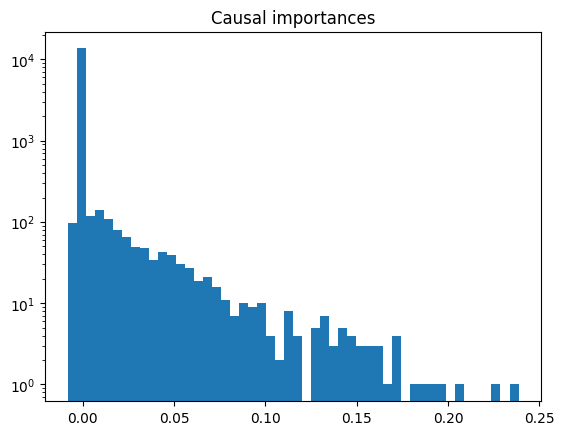

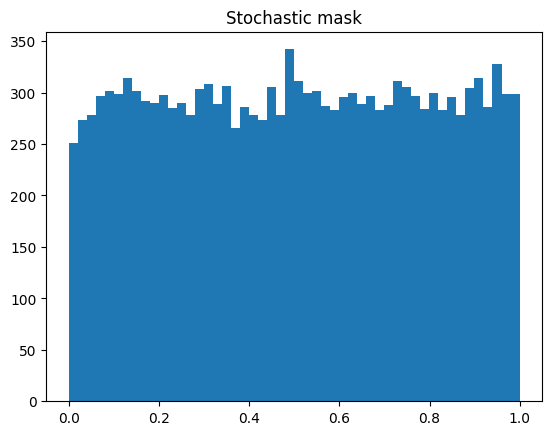

In [28]:
# stochastic_masks, causal_importances
# plot both as a hist
from matplotlib import pyplot as plt
module_name = 'transformer.h.3.mlp.c_fc'
plt.hist(causal_importances[module_name].cpu().flatten().numpy(), bins=50)
plt.yscale('log')
plt.title("Causal importances")
plt.show()

plt.hist(stochastic_masks[module_name].cpu().flatten().numpy(), bins=50)
plt.title("Stochastic mask")
plt.show()

In [9]:
# kl_div = F.kl_div(logits_stochastic, orig_logits, reduction='batchmean')
# print(f"KL-divergence stoch: {kl_div}")
# kl_div_o = F.kl_div(orig_logits, logits, reduction='batchmean')
# print(f"KL-divergence orig: {kl_div_o}")

# Above is nans, do log-softmax


KL-divergence stoch: 2.390738010406494
KL-divergence orig: 4.31406307220459


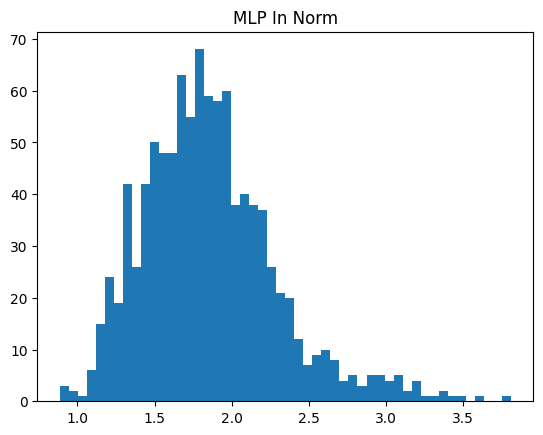

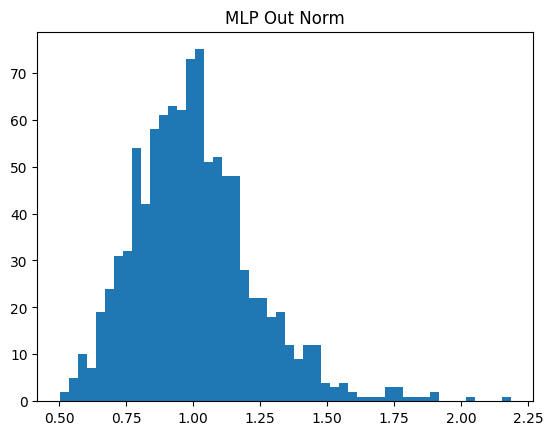

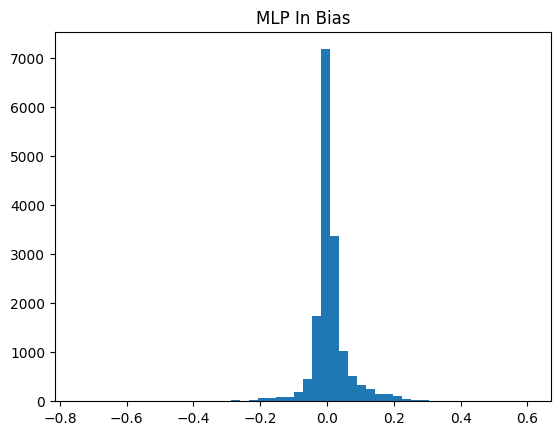

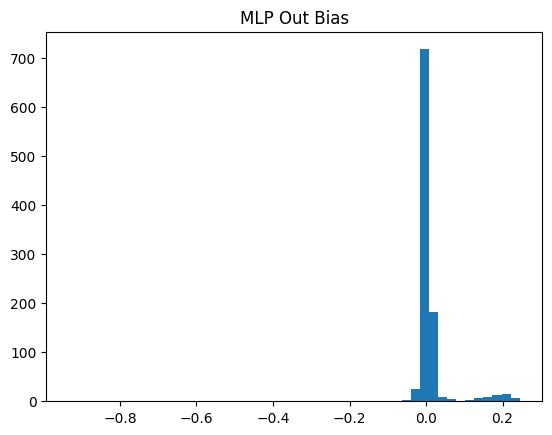

In [3]:
# Let's just plot a bunch of histograms
m_name = "transformer-h-2-mlp-c_fc"
mlp_in_norm = model.gates[m_name].mlp_in.norm(dim=-1)
mlp_out_norm = model.gates[m_name].mlp_out.norm(dim=-1)
from matplotlib import pyplot as plt
plt.hist(mlp_in_norm.cpu().numpy(), bins=50)
plt.title("MLP In Norm")
plt.show()
plt.hist(mlp_out_norm.cpu().numpy(), bins=50)
plt.title("MLP Out Norm")
plt.show()

# biases 
in_bias = model.gates[m_name].in_bias.flatten()
out_bias = model.gates[m_name].out_bias
plt.hist(in_bias.cpu().numpy(), bins=50)
plt.title("MLP In Bias")
plt.show()
plt.hist(out_bias.cpu().numpy(), bins=50)
plt.title("MLP Out Bias")
plt.show()
# weights

In [4]:
# Plot the range of values for the causal components (ie the target_component_acts)
target_component_acts[m_name.replace("-", ".")][:, :, 0]

tensor([[ 0.0100, -0.0066, -0.0218,  0.0231,  0.0178, -0.0137, -0.0027,  0.0077],
        [ 0.0265, -0.0077, -0.0041, -0.0351, -0.0103,  0.0147,  0.0177, -0.0278]],
       device='cuda:0')

In [14]:
def collate_fn(examples):
    texts = [ex['text'] for ex in examples]
    tokenized = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors='pt'
    )
    return tokenized

dataloader = DataLoader(
    dataset,
    batch_size=32,
    collate_fn=collate_fn,
    shuffle=False
)
module_name = "transformer-h-2-mlp-c_fc"

seq_len = 64

max_datapoints = 1_000
activations_storage = {}
gate_outputs = {}
for module_name, comp_indices in target_modules.items():
    n_components = components[module_name].A.shape[-1]
    activations_storage[module_name] = torch.zeros(max_datapoints, seq_len, n_components)
    gate_outputs[module_name] = torch.zeros(max_datapoints, seq_len, n_components)
module_comp = [key.replace('-', '.') for key in model.components.keys()]
components = {
    k.removeprefix("components.").replace("-", "."): v for k, v in model.components.items()
}
As = {module_name: components[module_name].A for module_name in components}

# If target_modules not specified, track all

total_processed = 0

with torch.no_grad():
    for batch_idx, batch in tqdm(enumerate(dataloader)):
        # print(f"Batch {batch_idx}")
        if total_processed >= max_datapoints:
            break
            
        input_ids = batch['input_ids'].to(device)
        batch_size = input_ids.shape[0]
        
        # Determine how many to process
        n_to_process = min(batch_size, max_datapoints - total_processed)
        
        # Get activations
        _, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
            input_ids[:n_to_process],
            module_names=module_comp
        )
        
        # Calculate component activations
        target_component_acts = calc_component_acts(
            pre_weight_acts=pre_weight_acts, 
            As=As
        )
        masks, sparsity_masks = calc_masks(
                gates=gates, target_component_acts=target_component_acts, detach_inputs=False
        )
        for module_name, comp_indices in target_modules.items():
            if module_name not in target_component_acts:
                continue
            acts = target_component_acts[module_name]
            activations_storage[module_name][total_processed:total_processed + n_to_process] = acts.cpu()
            gate_outputs[module_name][total_processed:total_processed + n_to_process] = masks[module_name].cpu()

        total_processed += n_to_process

3it [00:00, 22.53it/s]

32it [00:01, 21.71it/s]


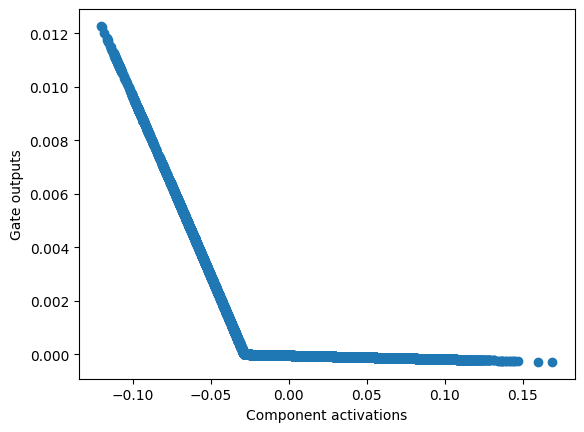

In [15]:
from matplotlib import pyplot as plt
x_acts = activations_storage['transformer.h.2.mlp.c_fc'][:, :, 0].flatten().cpu().numpy()
y_acts = gate_outputs['transformer.h.2.mlp.c_fc'][:, :, 0].flatten().cpu().numpy()
plt.scatter(x_acts, y_acts)
plt.xlabel("Component activations")
plt.ylabel("Gate outputs")
plt.show()

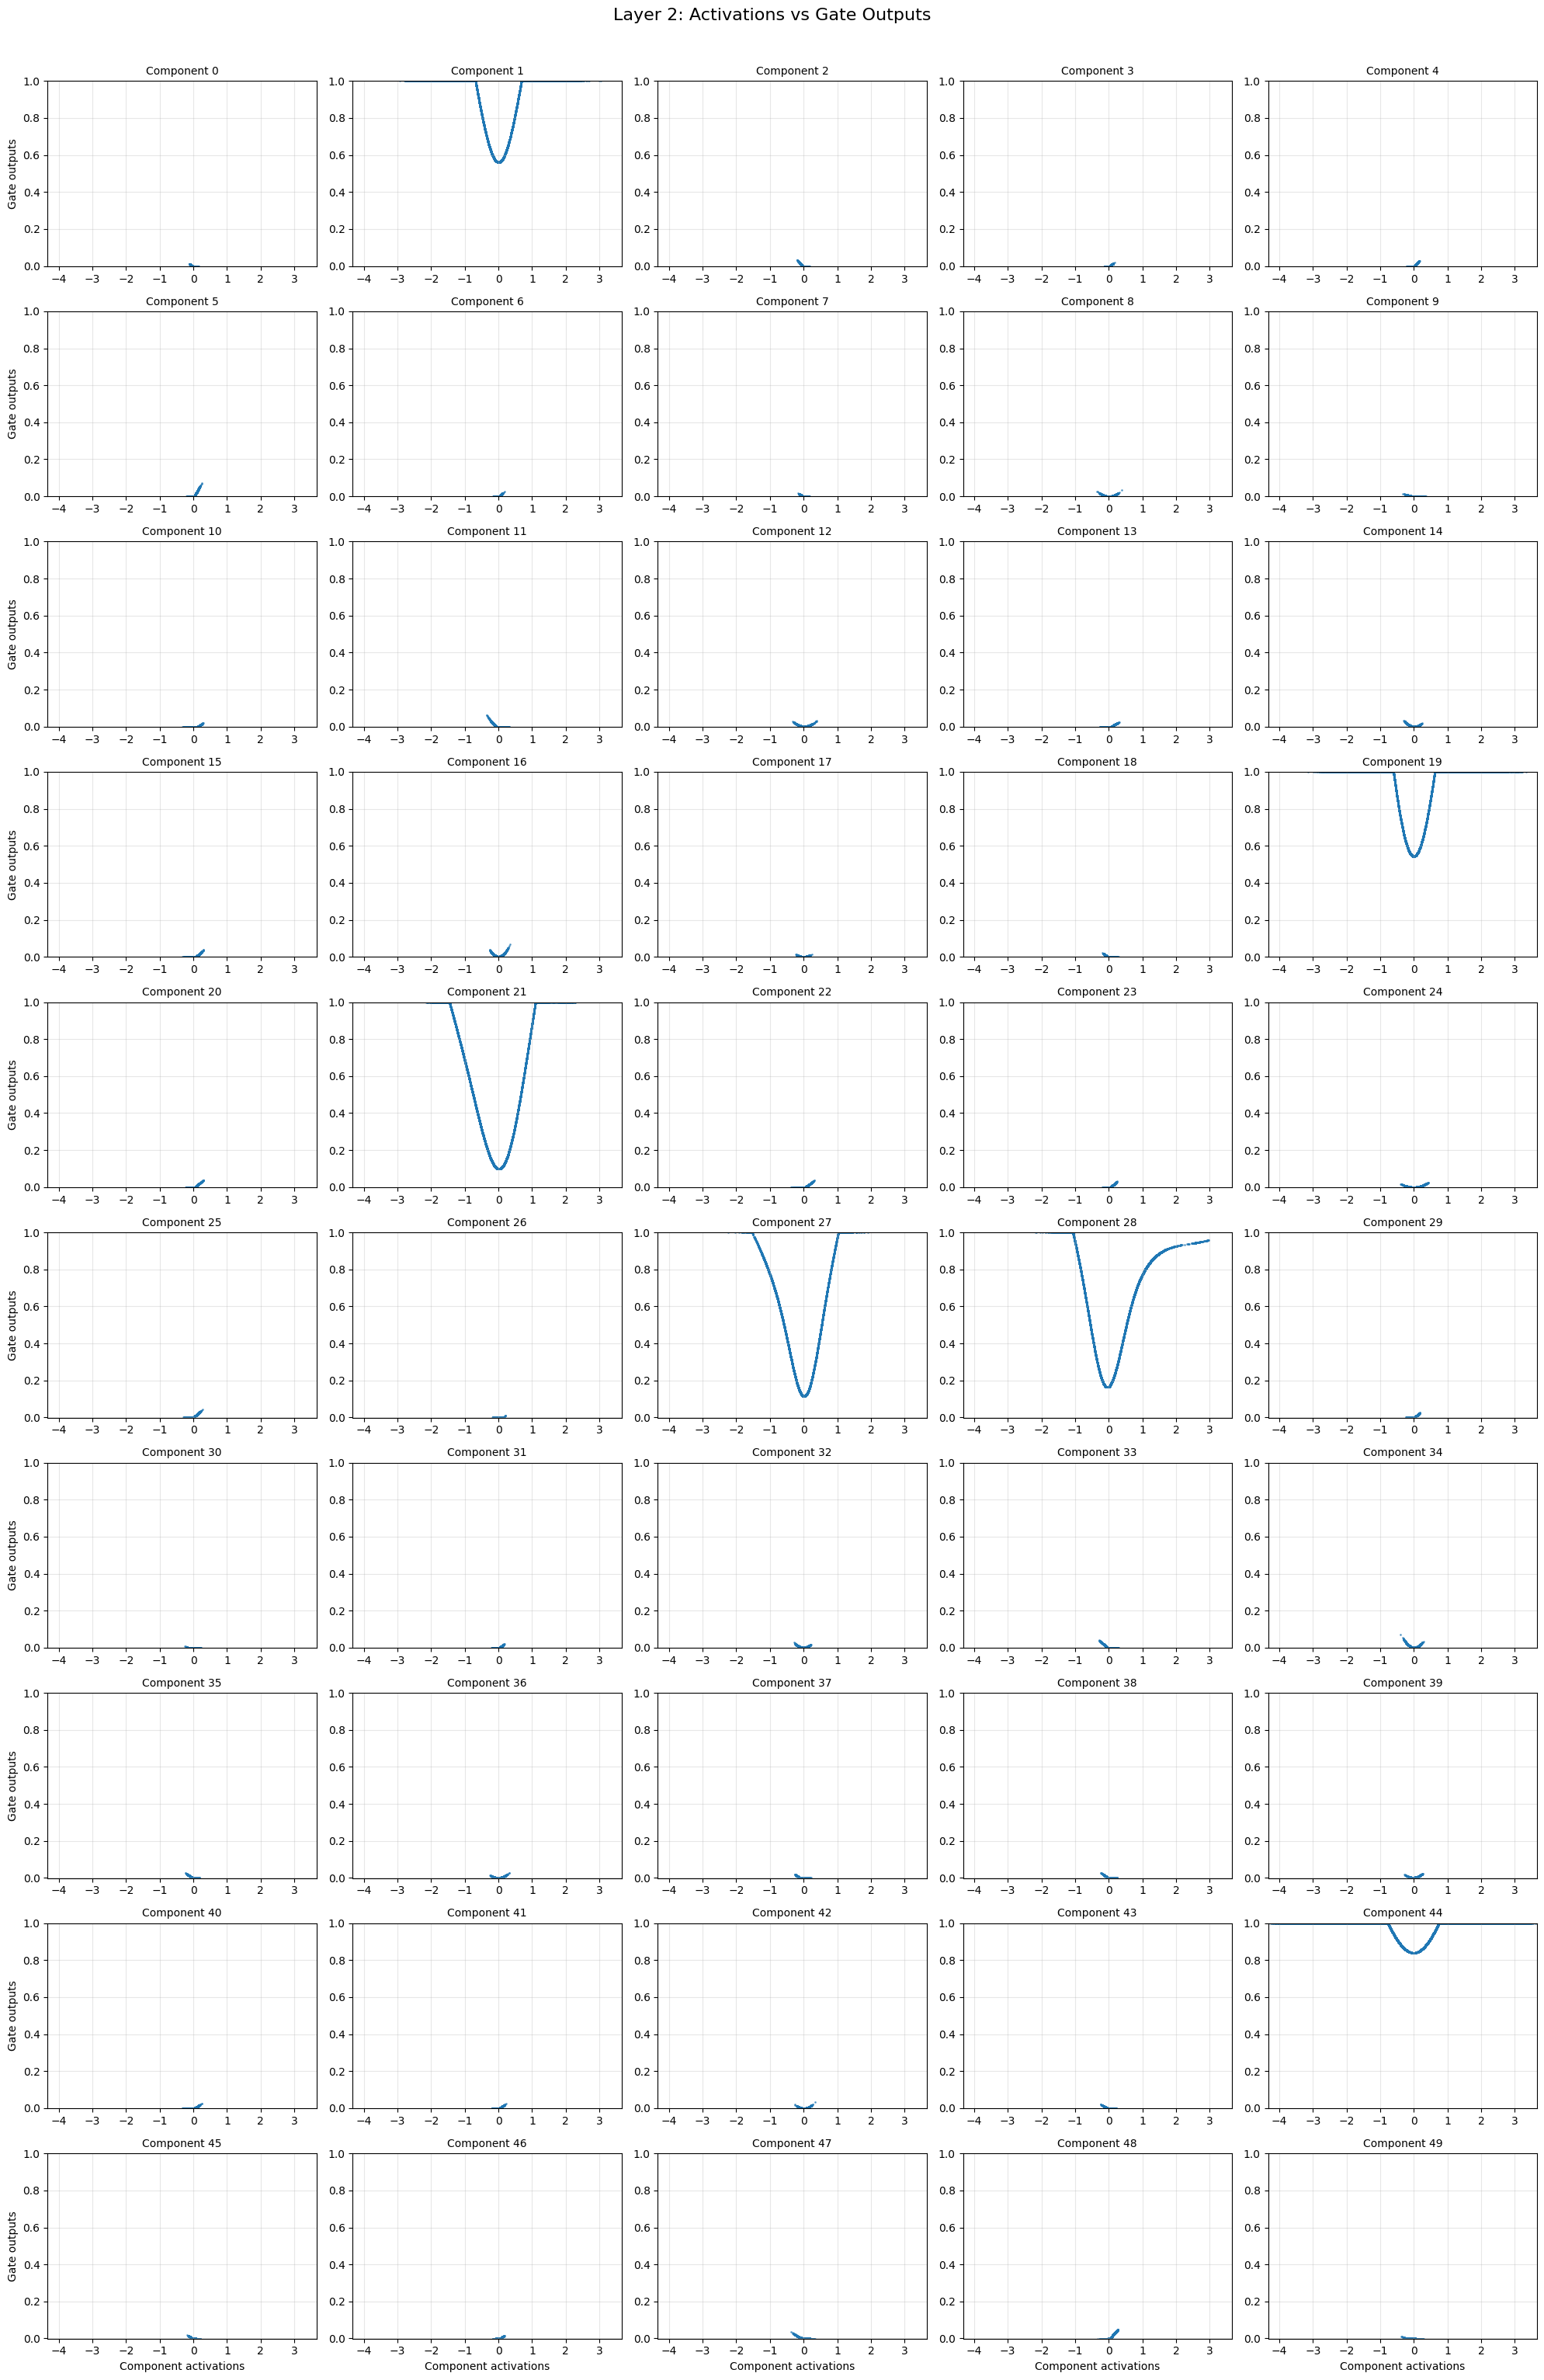

In [19]:
from matplotlib import pyplot as plt
import numpy as np




# Alternative: If you want to plot different components instead of layers
def plot_components_grid(activations_storage, gate_outputs, n_rows=3, n_cols=4, 
                        same_scale=True, layer_idx=2, component_indices=None):
    """
    Plot multiple components from the same layer in a grid.
    
    Args:
        activations_storage: Dict containing activation data
        gate_outputs: Dict containing gate output data
        n_rows: Number of rows in grid
        n_cols: Number of columns in grid
        same_scale: Whether to use same scale for all plots
        layer_idx: Which layer to plot from
        component_indices: List of component indices to plot (if None, plots 0 to n_rows*n_cols-1)
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    if component_indices is None:
        component_indices = list(range(n_rows * n_cols))
    
    key = f'transformer.h.{layer_idx}.mlp.c_fc'
    
    # Find global scale if needed
    if same_scale:
        global_x_min, global_x_max = float('inf'), float('-inf')
        global_y_min, global_y_max = float('inf'), float('-inf')
        
        for comp_idx in component_indices[:n_rows * n_cols]:
            try:
                x_acts = activations_storage[key][:, :, comp_idx].flatten().cpu().numpy()
                y_acts = gate_outputs[key][:, :, comp_idx].flatten().cpu().numpy()
                
                global_x_min = min(global_x_min, x_acts.min())
                global_x_max = max(global_x_max, x_acts.max())
                global_y_min = min(global_y_min, y_acts.min())
                global_y_max = max(global_y_max, y_acts.max())
            except IndexError:
                pass
    
    # Plot each component
    for i, (ax, comp_idx) in enumerate(zip(axes, component_indices)):
        if i >= n_rows * n_cols:
            break
        
        try:
            x_acts = activations_storage[key][:, :, comp_idx].flatten().cpu().numpy()
            y_acts = gate_outputs[key][:, :, comp_idx].flatten().cpu().numpy()
            
            ax.scatter(x_acts, y_acts, alpha=0.6, s=1)
            
            if i >= (n_rows - 1) * n_cols:
                ax.set_xlabel("Component activations", fontsize=10)
            if i % n_cols == 0:
                ax.set_ylabel("Gate outputs", fontsize=10)
            
            ax.set_title(f"Component {comp_idx}", fontsize=10)
            
            if same_scale:
                ax.set_xlim(global_x_min, global_x_max)
                ax.set_ylim(global_y_min, global_y_max)
            
            ax.grid(True, alpha=0.3)
            
        except IndexError:
            ax.set_visible(False)
    
    plt.tight_layout()
    fig.suptitle(f"Layer {layer_idx}: Activations vs Gate Outputs", fontsize=16, y=1.02)
    plt.show()
# Configuration variables
n_rows = 10  # Number of rows in the grid
n_cols = 5  # Number of columns in the grid
# same_scale = False  # Whether to use the same scale for all subplots
same_scale = True  # Whether to use the same scale for all subplots

# Example usage:
plot_components_grid(activations_storage, gate_outputs, n_rows=n_rows, n_cols=n_cols, same_scale=same_scale, layer_idx=2)

In [21]:
mod_acts = activations_storage[module_name]

# for i in range(10):
    # plt

plt.scatter(mod_acts[:, 0, 0], pre_weight_acts[:, 0, 0])

TypeError: unhashable type: 'slice'